In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob

In [ ]:
df = pd.read_csv("twitter_training.csv")

df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

(74681, 4)
Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None
2401                                                       0
Borderlands                                                0
Positive                                                   0
im getting on bo

In [4]:
df.columns = ['ID','Topic','Sentiment','Comment']

In [5]:
df.dropna(inplace=True)

In [8]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

df["Clean_Comment"] = df["Comment"].astype(str).apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


,ID,Topic,Sentiment,Comment,Clean_Comment
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming border kill
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderland kill
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderland murder
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderland murder
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,im getting borderland murder


In [9]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df["Polarity"] = df["Clean_Comment"].apply(get_polarity)

In [10]:
def sentiment_label(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Polarity"].apply(sentiment_label)

In [11]:
print(df["Predicted_Sentiment"].value_counts())

Predicted_Sentiment
Positive    32658
Negative    21543
Neutral     19794
Name: count, dtype: int64


In [12]:
vectorizer = CountVectorizer(max_features=20)

X = vectorizer.fit_transform(df["Clean_Comment"])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

trend = pd.DataFrame({
    "Word": words,
    "Count": counts
})

trend = trend.sort_values(by="Count", ascending=False)

print(trend)

       Word  Count
3      game  10351
8      like   4961
6        im   4941
4       get   4368
11      one   3716
13     play   3613
5      good   3565
19     time   3498
9      love   3322
15   really   3260
10      new   3210
12   people   2918
7   johnson   2897
17     shit   2806
16      see   2790
1      cant   2728
2      dont   2667
0      best   2496
18    still   2452
14   player   2386


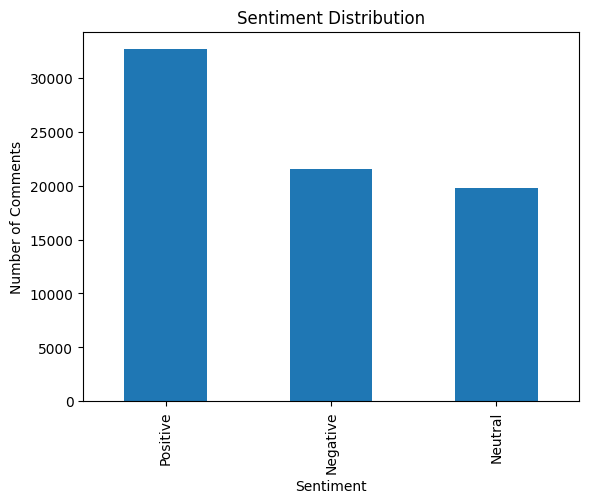

In [13]:
df["Predicted_Sentiment"].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Comments")

plt.show()

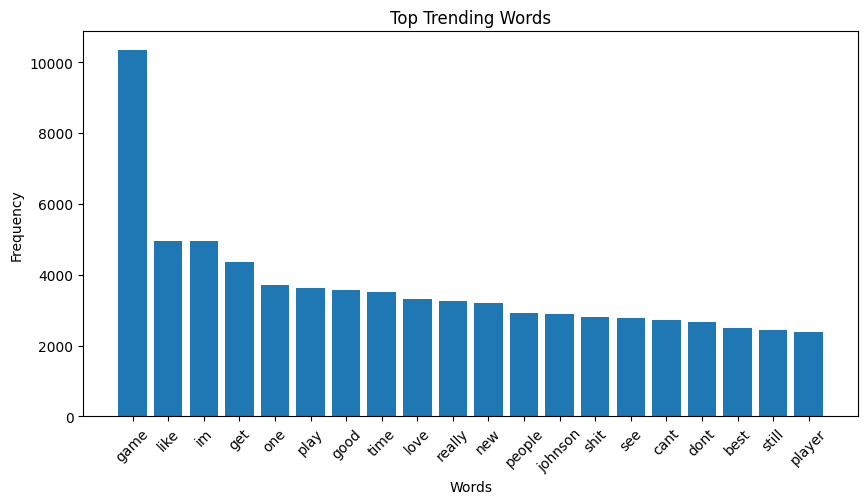

In [14]:
plt.figure(figsize=(10,5))

plt.bar(trend["Word"], trend["Count"])

plt.xticks(rotation=45)

plt.title("Top Trending Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()